# EV Purchase Prediction：Random Forest、SVM 与最佳模型集成

## tl;dr

- 公开榜反馈显示 `max_bin=4096` 双种子 XGBoost 集成为 `0.94313`，略高于 `max_bin=8192` 单模型的 `0.94311`。
- 新测试的标准 Random Forest 留出集 ROC-AUC 为 `0.939658`，XGBoost Random Forest 为 `0.939390`，线性 SVM 最高为 `0.937208`，均未超过 fine-bin XGBoost 的 `0.942993`。
- 对每个新模型进行 1%–30% 的排名融合权重搜索，最佳权重全部为 `0%`；新模型没有提供足以抵消精度差距的互补排序。
- 基于公开榜最好的两个高质量模型，生成了以 `4096` 双种子集成为主的 `75/25`、`90/10` 概率融合和 `75/25` 排名融合。
- 当前最合理的下一次提交是 `submission_top2_probability_blend_75_25.csv`，其次是更保守的 `90/10` 概率融合。

## Context & Methods

### 最佳两个模型的共同思路

两个公开榜最佳模型使用完全相同的特征工程：充电站总量、最小值、最大值、家庭与工作地点差值、通勤/充电站比率、收入对数、每辆车收入、收入/通勤距离、环境关注交互、收入与补贴交互、续航焦虑交互，以及补贴、焦虑、家庭充电和环境关注组成的核心条件上下文。

它们的主要区别是：

- `4096` 模型使用两个随机种子平均，重点是降低方差。
- `8192` 模型使用更细的直方图分箱，重点是保留收入和通勤距离的连续细节。

公开榜显示前者略优，说明在当前测试集上降方差的价值稍高于进一步提高单模型分辨率。

### 实验方法

- 固定训练、调优和独立留出划分。
- 新模型与 fine-bin XGBoost 使用相同的人工特征和样本。
- SVM 使用 MaxAbs 缩放，避免收入量纲主导线性间隔。
- 所有融合权重只在调优集搜索，留出集只用于最终验证。

## Data

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve().parent
ARTIFACT_DIR = ROOT / "artifacts"
SUBMISSION_DIR = ROOT / "submissions"
TARGET = "Will_Buy_EV"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.titleweight"] = "bold"

model_results = pd.read_csv(ARTIFACT_DIR / "rf_svm_model_comparison.csv")
ensemble_results = pd.read_csv(ARTIFACT_DIR / "rf_svm_pairwise_ensembles.csv")
with open(ARTIFACT_DIR / "rf_svm_experiment_summary.json", encoding="utf-8") as file:
    experiment_summary = json.load(file)

model_results

,Model,Fit_Seconds,Tuning_ROC_AUC,Tuning_Average_Precision,Holdout_ROC_AUC,Holdout_Average_Precision
0,XGBoost_FineBin_Reference,62.263193,0.942951,0.763260,0.942993,0.764391
1,Sklearn_RandomForest,99.987364,0.939545,0.749873,0.939658,0.749368
2,XGBoost_RandomForest,11.681859,0.939016,0.745055,0.939390,0.745027
3,LinearSVM_C_1,124.957125,0.936444,0.742574,0.937208,0.742947
4,LinearSVM_C_0.01,10.694162,0.936524,0.742181,0.937074,0.742242
5,LinearSVM_C_0.1,30.952337,0.935259,0.742033,0.936183,0.742280


## Results

### 1. 公开榜最佳模型

In [2]:
public_scores = pd.DataFrame({
    "Model": [
        "XGBoost FineBin 4096 Seed Ensemble",
        "XGBoost FineBin 8192 Seed 42",
    ],
    "Public_ROC_AUC": [0.94313, 0.94311],
    "Design": ["Variance reduction", "Higher continuous resolution"],
})
public_scores

,Model,Public_ROC_AUC,Design
0,XGBoost FineBin 4096 Seed Ensemble,0.94313,Variance reduction
1,XGBoost FineBin 8192 Seed 42,0.94311,Higher continuous resolution


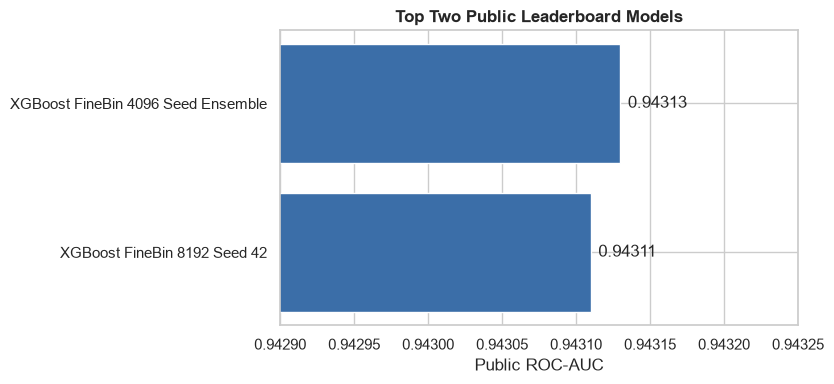

In [3]:
fig, axis = plt.subplots(figsize=(8.5, 4))
ordered = public_scores.sort_values("Public_ROC_AUC")
axis.barh(ordered["Model"], ordered["Public_ROC_AUC"], color="#3B6EA8")
axis.set_xlim(0.9429, 0.94325)
axis.set_xlabel("Public ROC-AUC")
axis.set_title("Top Two Public Leaderboard Models")
for index, value in enumerate(ordered["Public_ROC_AUC"]):
    axis.text(value + 0.000005, index, f"{value:.5f}", va="center")
plt.tight_layout()
plt.show()

两者只相差 `0.00002`，不能视为显著差异，但它支持将更多融合权重分配给多种子 `4096` 模型，而不是继续单纯增加分箱数量。

### 2. Random Forest 与 SVM 对比

In [4]:
model_results[[
    "Model",
    "Fit_Seconds",
    "Tuning_ROC_AUC",
    "Holdout_ROC_AUC",
    "Holdout_Average_Precision",
]].sort_values("Holdout_ROC_AUC", ascending=False)

,Model,Fit_Seconds,Tuning_ROC_AUC,Holdout_ROC_AUC,Holdout_Average_Precision
0,XGBoost_FineBin_Reference,62.263193,0.942951,0.942993,0.764391
1,Sklearn_RandomForest,99.987364,0.939545,0.939658,0.749368
2,XGBoost_RandomForest,11.681859,0.939016,0.939390,0.745027
3,LinearSVM_C_1,124.957125,0.936444,0.937208,0.742947
4,LinearSVM_C_0.01,10.694162,0.936524,0.937074,0.742242
5,LinearSVM_C_0.1,30.952337,0.935259,0.936183,0.742280


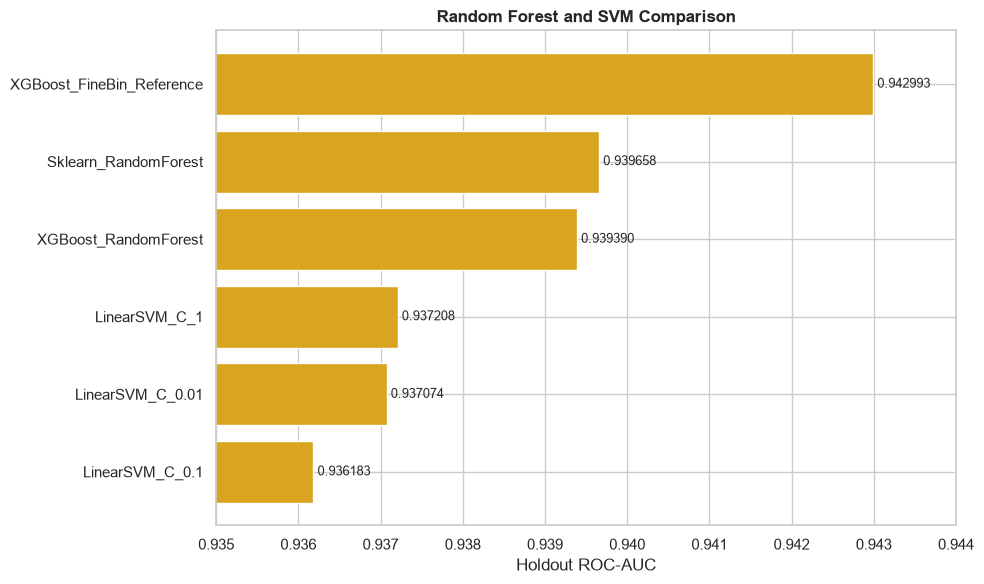

In [5]:
ordered = model_results.sort_values("Holdout_ROC_AUC")
fig, axis = plt.subplots(figsize=(10, 6))
axis.barh(ordered["Model"], ordered["Holdout_ROC_AUC"], color="#D9A520")
axis.set_xlim(0.935, 0.944)
axis.set_xlabel("Holdout ROC-AUC")
axis.set_title("Random Forest and SVM Comparison")
for index, value in enumerate(ordered["Holdout_ROC_AUC"]):
    axis.text(value + 0.00005, index, f"{value:.6f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

Random Forest 的 bagging 能提供稳定概率，但对环境关注、补贴、焦虑与连续收入之间的分段交互刻画不足。线性 SVM 即使使用交互特征和缩放，也受到线性决策边界限制。RBF SVM 在 66.9 万样本上的时间和内存复杂度过高，不适合作为本地完整训练方案。

### 3. 新模型是否具有融合价值

In [6]:
ensemble_results.sort_values("Holdout_ROC_AUC", ascending=False)

,Candidate,Candidate_Weight,Tuning_ROC_AUC,Holdout_ROC_AUC
0,XGBoost_RandomForest,0.0,0.942951,0.942993
1,Sklearn_RandomForest,0.0,0.942951,0.942993
2,LinearSVM_C_0.01,0.0,0.942951,0.942993
3,LinearSVM_C_0.1,0.0,0.942951,0.942993
4,LinearSVM_C_1,0.0,0.942951,0.942993


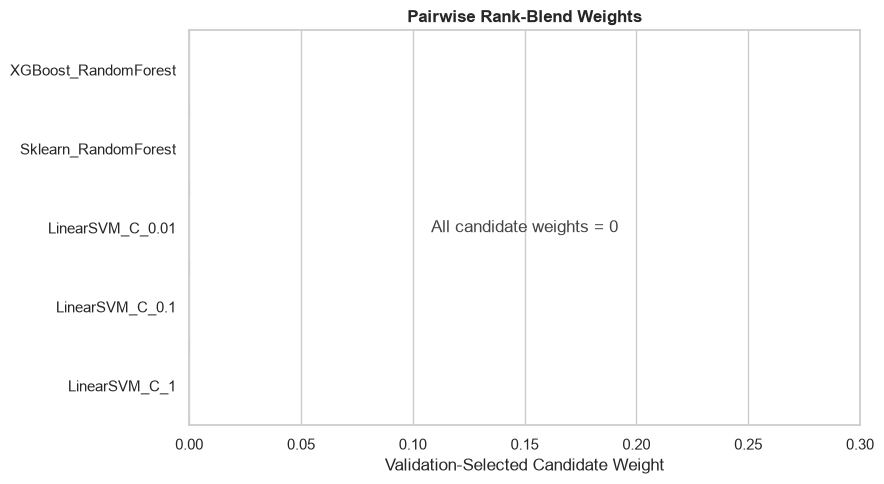

In [7]:
fig, axis = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=ensemble_results.sort_values("Candidate_Weight", ascending=False),
    y="Candidate",
    x="Candidate_Weight",
    color="#E46A2E",
    ax=axis,
)
axis.set_xlim(0, 0.30)
axis.set_xlabel("Validation-Selected Candidate Weight")
axis.set_ylabel("")
axis.set_title("Pairwise Rank-Blend Weights")
if ensemble_results["Candidate_Weight"].max() == 0:
    axis.text(
        0.15,
        len(ensemble_results) / 2 - 0.5,
        "All candidate weights = 0",
        ha="center",
        va="center",
        fontsize=12,
        color="#444444",
    )
plt.tight_layout()
plt.show()

所有候选的最优权重都是 `0%`。这说明它们虽然预测不完全相同，但错误排序质量太低；加入后无法改善调优集 AUC，因此不应为了“模型多样性”进行等权融合。

### 4. 两个最佳模型的公开榜反馈融合

In [8]:
submission_files = {
    "FineBin_4096_Seed_Ensemble": "submission_xgboost_finebin_4096_seed_ensemble.csv",
    "FineBin_8192_Seed_42": "submission_xgboost_finebin_8192_seed_42.csv",
    "Probability_75_25": "submission_top2_probability_blend_75_25.csv",
    "Probability_90_10": "submission_top2_probability_blend_90_10.csv",
    "Rank_75_25": "submission_top2_rank_blend_75_25.csv",
}
submission_predictions = pd.DataFrame({
    name: pd.read_csv(SUBMISSION_DIR / filename)[TARGET]
    for name, filename in submission_files.items()
})
submission_summary = submission_predictions.agg(["mean", "std", "min", "max"]).T
submission_summary

,mean,std,min,max
FineBin_4096_Seed_Ensemble,0.174700,0.270457,0.000009,0.999394
FineBin_8192_Seed_42,0.174711,0.270512,0.000009,0.999339
Probability_75_25,0.174703,0.270460,0.000009,0.999380
Probability_90_10,0.174701,0.270457,0.000009,0.999388
Rank_75_25,0.500002,0.288662,0.000003,1.000000


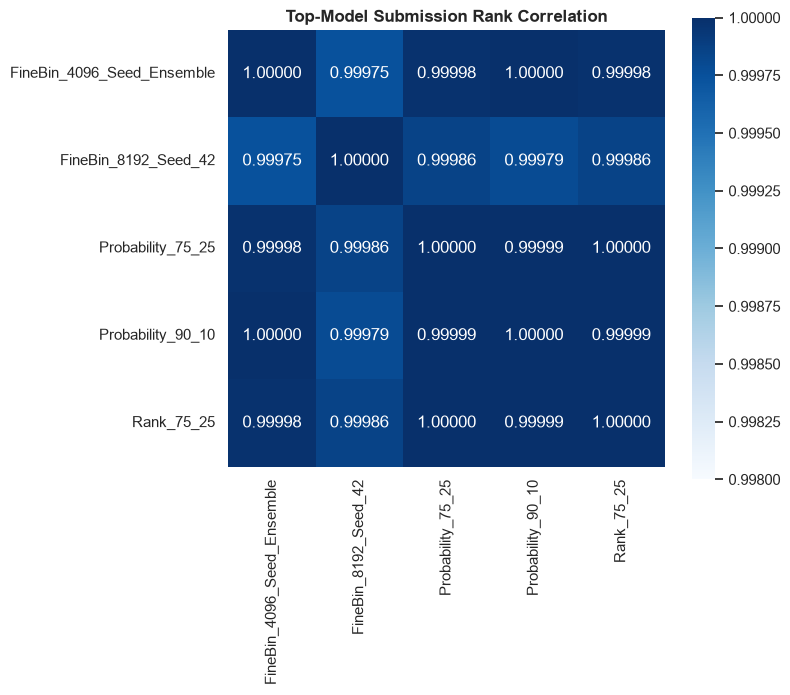

In [9]:
correlation = submission_predictions.corr(method="spearman")
fig, axis = plt.subplots(figsize=(8, 7))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".5f",
    cmap="Blues",
    vmin=0.998,
    vmax=1.0,
    square=True,
    ax=axis,
)
axis.set_title("Top-Model Submission Rank Correlation")
plt.tight_layout()
plt.show()

两个最佳模型高度相关，因此融合预期是小幅降低边界样本方差，而不是形成大幅跃升。`75/25` 提供更多 `8192` 连续细节，`90/10` 则更保守地保留公开榜最佳 `4096` 排序。

## Takeaways

### 推荐提交顺序

1. `submission_top2_probability_blend_75_25.csv`
2. `submission_top2_probability_blend_90_10.csv`
3. `submission_top2_rank_blend_75_25.csv`

不要优先提交单独的 Random Forest 或线性 SVM；验证结果不支持它们超过现有最佳模型。

### 结论

- 当前任务最有效的归纳偏置仍是高分辨率 boosting，而不是 bagging 或线性大间隔分类。
- `4096` 多种子集成略优于 `8192` 单模型，说明下一步更值得增加强模型种子或折数，而不是继续提高 `max_bin`。
- 若继续尝试支持向量方法，应使用近似核或 GPU 加速的大规模 SVM；这需要新依赖或不同硬件，安装前应单独确认。

### Reproducible artifacts

- `compare_rf_svm_models.py`
- `create_top_model_blends.py`
- `artifacts/rf_svm_model_comparison.csv`
- `artifacts/rf_svm_pairwise_ensembles.csv`